# Практическое домашнее задание 1. Поиск похожих изображений с помощью SVD.

Версия от 19.02.2024.

В этой задаче мы познакомимся с одним из возможных приложений сингулярного разложения — поиск "хорошего" базиса (eigenfaces) в наборе изображений и использования его для поиска похожих изображений.

**Замечание:** пользоваться циклами по изображениям **запрещено**, если это явно не прописано в условии.

Для этого сначала загрузим набор изображений, на котором будем обучаться. Это набор фотографий лиц, взятый с [сайта](http://vis-www.cs.umass.edu/lfw/) проекта "Labeled faces in the wild". Скачайте лица людей с именами, начинающимися на "А" и положите в папку `data/` в рабочей директории ноутбука.

Импортируем необходимые библиотеки и загрузим картинки в виде numpy-массивов. 

In [1]:
import matplotlib.pyplot as plt
import PIL
import tarfile
import os
import numpy as np
from PIL import Image

def load_images(targz, size):
    images = {}
    tar = tarfile.open(targz, "r:gz")
    for tarinfo in tar:
        if tarinfo.isreg():
            file = tar.extractfile(tarinfo)
            image = PIL.Image.open(file)
            image = image.convert("L")
            image = image.resize(size, PIL.Image.LANCZOS)
            image = np.asarray(image, dtype=np.double)
            image /= np.linalg.norm(image)
            parts = os.path.normpath(tarinfo.name).split(os.path.sep)
            images.setdefault(parts[-2], []).append(image)
    return images

In [2]:
size = 256
images = load_images("data/lfw-a.tgz", (size, size))

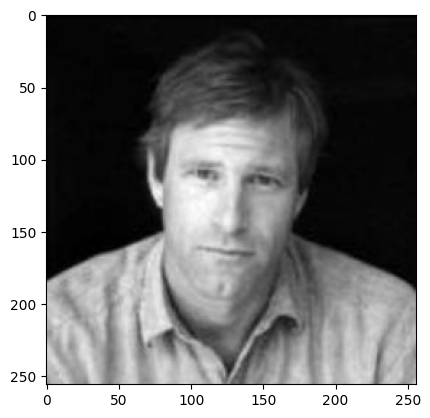

In [3]:
_ = plt.imshow(images["Aaron_Eckhart"][0], cmap="gray")

Сразу отложим одно изображение для последующего поиска.



In [5]:
test_image = images["Alejandro_Toledo"][10]
del images["Alejandro_Toledo"][10]

### a. Применение базового алгоритма SVD (35 баллов)

1. **(4 балла)** С помощью функции ```np.reshape(...)``` получите из словаря `images` массив ```M``` размера ```(size * size, nframes)```, каждым столбцом которого является изображение размера ```(size, size)```, представленное в виде вектора длины ```size**2``` (используйте такое значение параметра `order`, чтобы обходить картинки по столбцам).

*В этом пункте (и только в этом) можно использовать цикл по изображениям.*

In [6]:
# Создаем список для хранения изображений
images_list = []

# Проходим по всем изображениям
for image in images.values():
    for each in image:
        # Преобразуем каждое изображение в вектор и добавляем в список
        image_to_add = each.reshape(size * size, 1, order='F')
        images_list.append(image_to_add)

# Преобразуем список изображений в массив M
M = np.concatenate(images_list, axis=1)

2. **(10 баллов)** Вычислите сингулярное разложение матрицы ```M``` с помощью ```np.linalg.svd``` и постройте график сингулярных чисел, отсортированных по убыванию. Шкала с сингулярными числами должна быть логарифмической. Например, для этого можно использовать функцию ```plt.semilogy```.
 
    **Замечание:** При построении графиков величин с отличающимися на порядки значениями полезно использовать логарифмическую шкалу. Чтобы убедиться в этом, попробуйте построить график не в логарифмической шкале; из него будет фактически невозможно понять характер убывания сингулярных чисел.

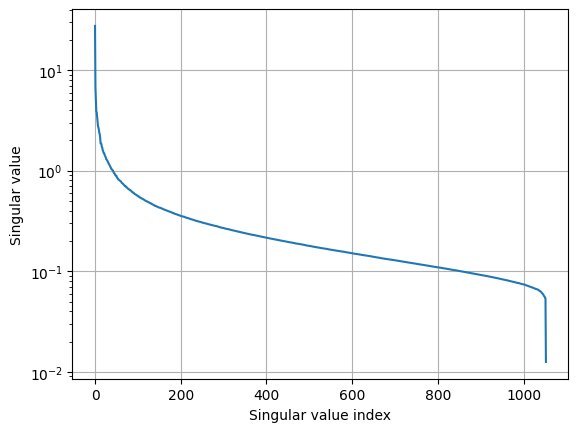

In [7]:
m_svd = np.linalg.svd(M, full_matrices=False)  # m_svd = U-0, S-1, Vt-2
plt.xlabel('Singular value index')
plt.ylabel('Singular value')
plt.grid(True)
plt.semilogy(m_svd[1])
plt.show()

 3. **(5 баллов)** Заполните пропуск в следующей функции, которая должна визуализировать вектор-столбцы нашей матрицы в виде таблицы. Затем с её помощью визуализируйте несколько первых сингулярных векторов. Опишите неформально, за что отвечают три старших сингулярных вектора.

In [8]:
def plot_as_images(mat, rows, cols):
    '''
        Visualize images from the columns of mat in a table of shape (rows, cols).

        Input
            mat: numpy array of shape (size * size, rows * cols)
            rows: number of rows in the table
            cols: number of columns in the table
    '''

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    for i in range(rows):
        for j in range(cols):
            axes[i, j].imshow(mat[:, i * cols + j].reshape((size, size), order='F'), cmap="gray")
            axes[i, j].get_xaxis().set_visible(False)
            axes[i, j].get_yaxis().set_visible(False)


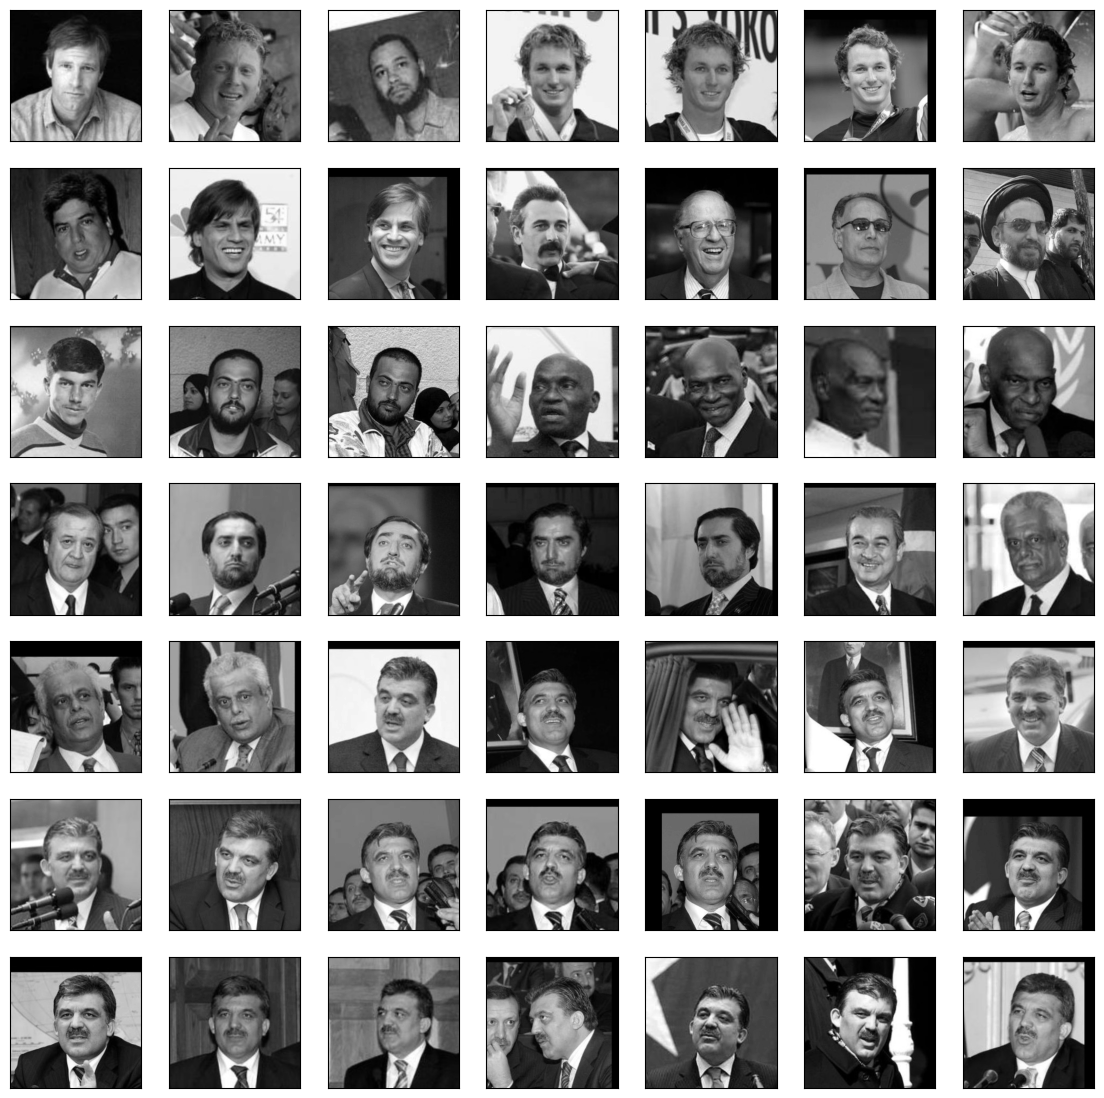

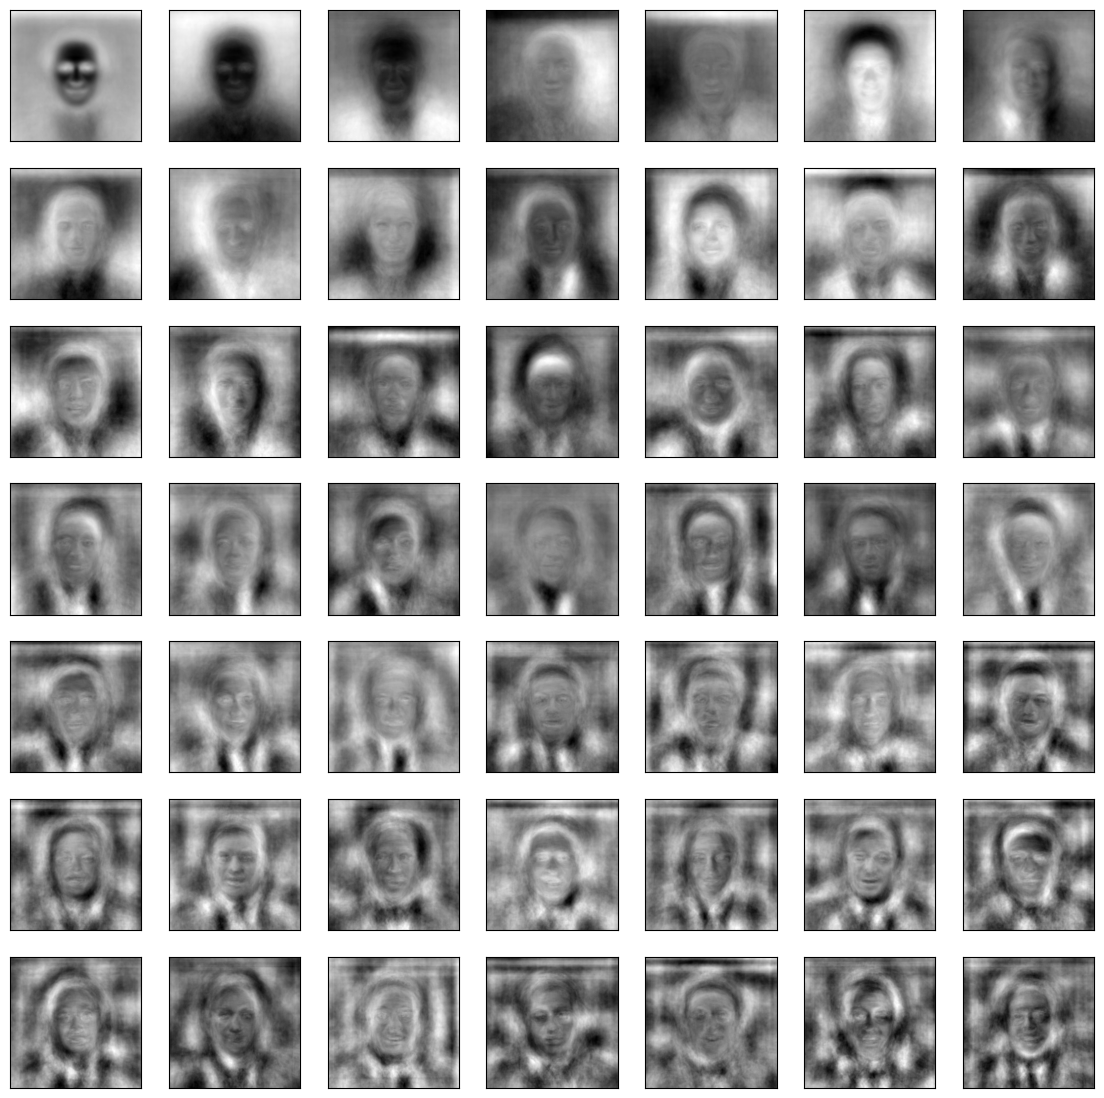

In [9]:
plot_as_images(M, 7, 7)
plot_as_images(m_svd[0], 7, 7)

Короч я не спец но мне кажется что сингулярные вектора отвечают за направления наибольшей дисперсии в данных => за наиболее важные признаки. Таким образом первые три сингулярных вектора отвечают за наиболее важные признаки в изображениях или прост паттерны самые частые в изображениях. Например, первый вектор может отвечать за освещение, второй за положение головы, третий за выражение лица и т.д.

4. **(10 баллов)** Напишите функцию ```trunc_svd(M, r)```, которая вычисляет оптимальное приближение $M_{r}$ двумерного массива $M$ заданного ранга. Функция должна возвращать матрицы $U$ и $C$ такие, что столбцы матрицы $U$ составляют ортонормированный базис столбцов $M_{r}$, а $UC = M_{r}$. Также функция `trunc_svd` возвращает **относительную** точность приближения во Фробениусовой норме, т.е.
$$
    \frac{\|M - M_{r}\|_F}{\|M\|_F}.
$$
Для вычисления относительной точности используйте только полученные из сингулярного разложения сингулярные числа.

In [10]:
def trunc_svd(M, r):
    '''
        Input
            M: original 2D numpy array
            r: rank value for truncation
            
        Output
            U: orthonormal basis of columns of Mr
            C: coefficients in equality Mr = UC
            rel_eps: relative error of rank-r approximation Mr
    '''

    # считаем свд
    U, S, Vt = np.linalg.svd(M, full_matrices=False)  # U-0, S-1, Vt-2
    U = U[:, :r]  # U_ = U[:, :r] до r-го столбца
    C = np.array(np.diag(S[:r]) @ Vt[:r, :])  # C = Сингулярные до r умноженные на Vt(левые вектора) до r
    Mr = np.array(U) @ C  # Mr = U_ @ C_
    rel_eps = np.sqrt(sum(S[r:] ** 2) / sum(S ** 2))  # равносильно норме Фробениуса ||M - Mr||_F / ||M||_F
    return U, C, rel_eps

5. **(6 баллов)** Проверим работу написанной функции. Для этого воспользуемся функцией, которая рисует исходное изображение, приближение некоторого ранга, а также первые `count` сингулярных векторов в разложении вместе с их коэффициентами. Заполните пропуски в ней с помощью метода `reshape`.

In [11]:
def plot_as_combination(M, U, C, count, indices):
    '''
        Input
            M: original 2D numpy array
            U: orthonormal basis of columns of Mr
            C: coefficients in equality Mr = UC
            count: desired number of images of singular vectors
            indices: indices of columns of M which are visualized
    '''

    fig, all_axes = plt.subplots(len(indices), count + 2, figsize=(count * 2, len(indices) * 2))

    for i, index in enumerate(indices):
        axes = all_axes[i, :]

        axes[0].imshow((M[:, index].reshape((size, size), order="F")), cmap="gray")  # Original image
        axes[0].set_xlabel("Orig")

        appr = U @ C[:, index]
        axes[1].imshow(appr.reshape((size, size), order="F"), cmap="gray")  # Approximation image
        axes[1].set_xlabel("Appr")

        for j in range(count):
            axes[2 + j].imshow(U[:, j].reshape((size, size), order="F"), cmap="gray")  # i-th singular vector image
        for ax in axes:
            ax.set_xticks([])
            ax.get_yaxis().set_visible(False)

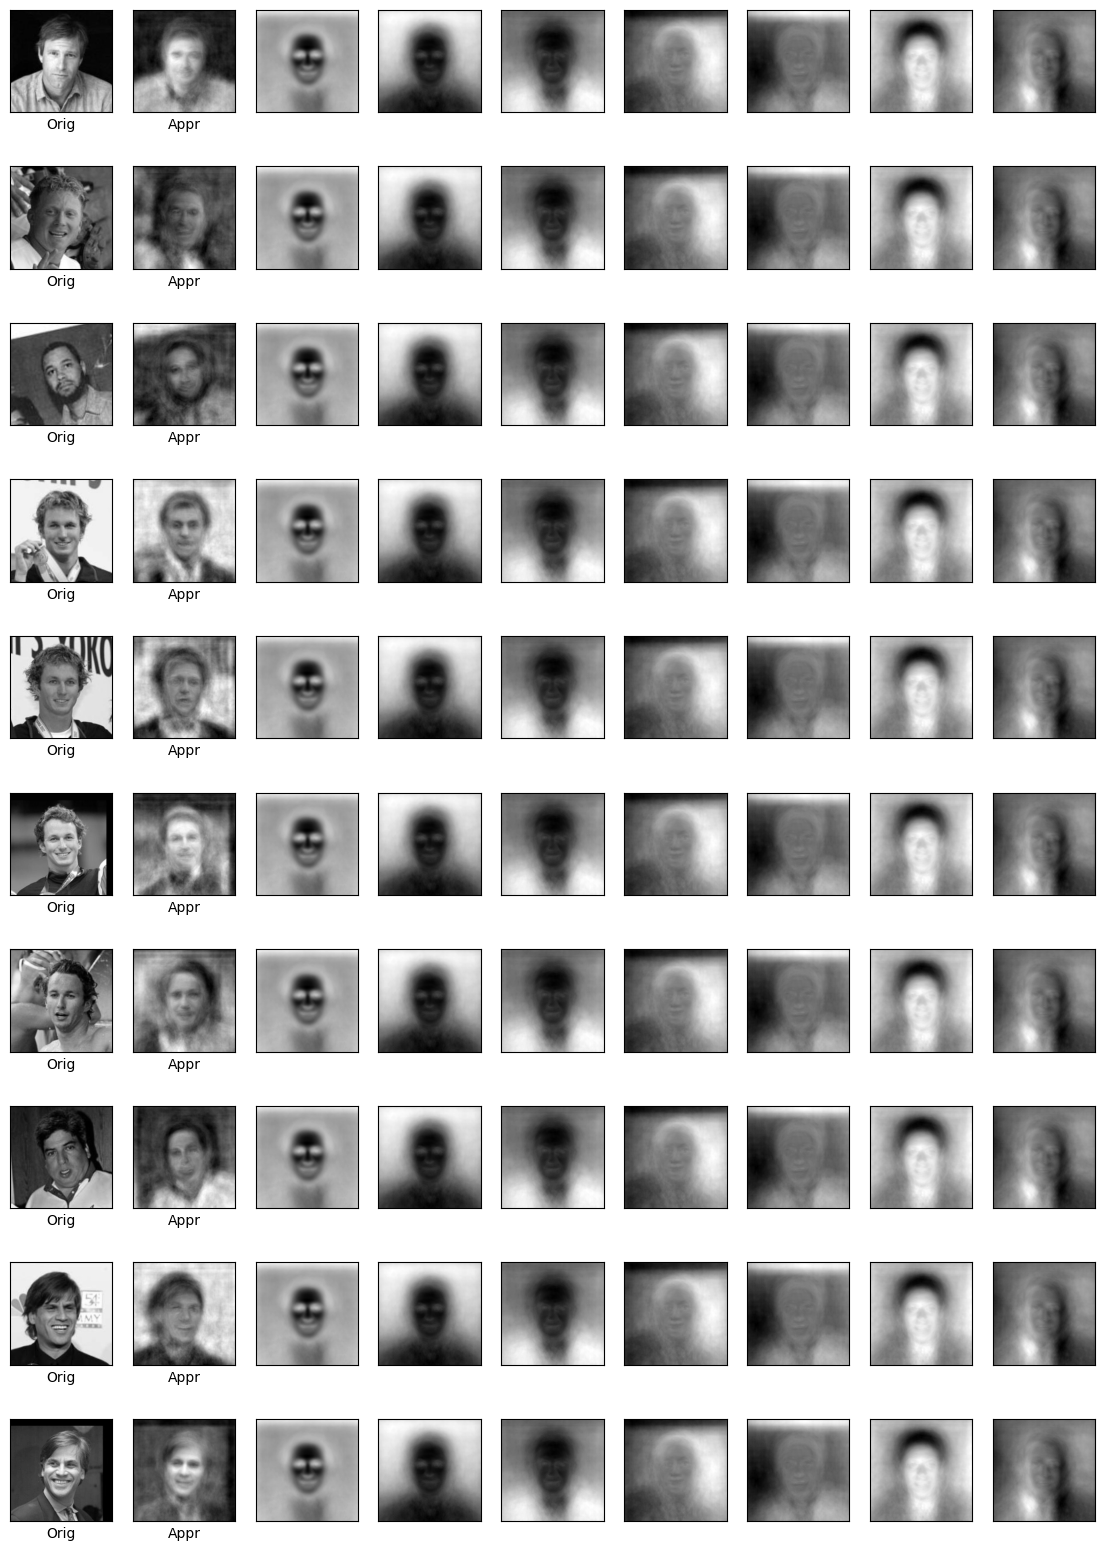

In [12]:
U, C, eps = trunc_svd(M, 100)
plot_as_combination(M, U, C, 7, range(10))

### b. Применение рандомизированного алгоритма SVD (35 баллов)

Использование функции ```np.linalg.svd``` является эффективным для относительно небольших массивов из-за быстрого (кубического) роста сложности алгоритма в зависимости от размера матрицы. Используем рандомизированный алгоритм из лекций для ускорения вычислений.

1. **(20 баллов)** Реализуйте рандомизированный алгоритм SVD из лекций, который аппроксимирует матрицу с заданным рангом $r$ (алгоритм запускается с ```r + p``` случайных векторов, после чего ранг обрезается до ```r``` с наименьшей ошибкой). Убедитесь, что вы **не вычисляете** в явном виде матрицу $QQ^*$.

In [13]:
def rand_svd(M, r, p=10):
    '''
        Input
            M: 2D numpy array
            r: rank value for truncation
            p: number of extra random vectors to approximate range(M)

        Output
            Mr: 2D numpy array of rank r and of the same size as M
            rel_eps: relative error of rank-r approximation Mr
    '''

    k = r + p  # число случайных векторов
    n = M.shape[1]  # число столбцов
    omega = np.random.randn(n, k)  # случайная матрица
    Y = M @ omega  # произведение M на случайную матрицу
    Q, R = np.linalg.qr(Y)  # QR разложение
    B = Q.T @ M  # произведение транспонированной Q на M
    U, S, Vh = np.linalg.svd(B, full_matrices=False)  # сингулярное разложение B
    first_component = Q @ U[:, :r]  # первая компонента
    Mr = first_component @ np.diag(S[:r]) @ Vh[:r,
                                            :]  # Mr = первая компонента умноженная на сингулярные числа и правые вектора
    rel_eps = np.linalg.norm(M - Mr, 'fro') / np.linalg.norm(M, 'fro')  # относительная ошибка
    return Mr, rel_eps



2. **(10 баллов)** Постройте график функции
$$
\frac{||M_{rand}(p) - M||_F}{||M_{SVD} - M||_F} - 1
$$
в зависимости от $p$ для $r=50$. По $p$ выберите сетку $[0, 100]$ с шагом 5.
Так как $M_{rand}(p)$ получено с помощью рандомизированного алгоритма, усредните Ваш результат, запустив алгоритм 10 раз.
При построении графика используйте логарифмическую шкалу.

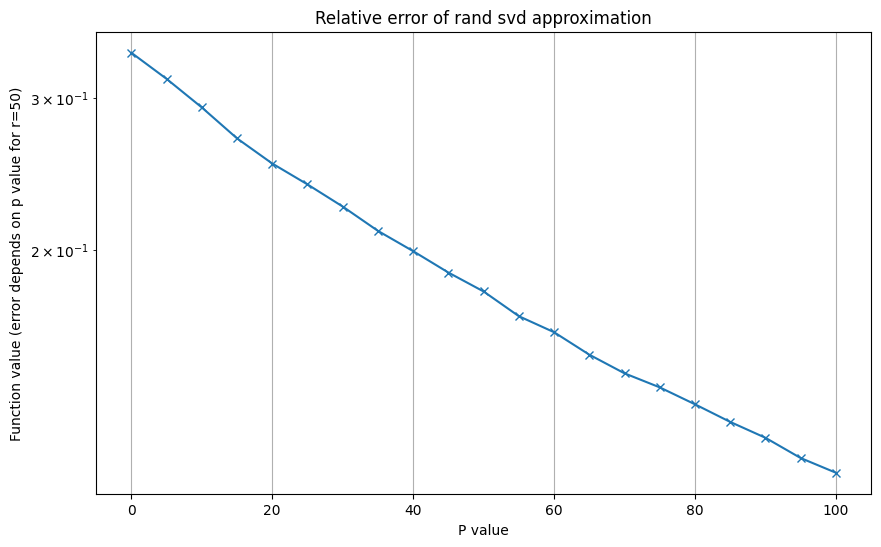

In [13]:
p_val = np.arange(0, 101, 5)  # сетка
r = 50
array_to_plot = []
U, S, Vt = np.linalg.svd(M, full_matrices=False)
M_svd = U[:, :r] @ np.diag(S[:r]) @ Vt[:r, :]
denomenator = np.linalg.norm(M_svd - M, ord='fro')
for p in p_val:
    funct_res = []
    for i in range(10):
        Mr, error1 = rand_svd(M, r, p)  # запускаем алгоритм 10 раз
        numerator = np.linalg.norm(Mr - M, ord='fro')  # считаем числитель
        funct_res.append((numerator / denomenator) - 1)  # считаем результат функции
    mean = np.mean(funct_res)  # усредняем результаты
    array_to_plot.append(mean)
plt.figure(figsize=(10, 6))
plt.semilogy(p_val, array_to_plot, marker='x')
plt.title('Relative error of rand svd approximation')
plt.xlabel('P value')
plt.ylabel('Function value (error depends on p value for r=50)')
plt.grid(True)
plt.show()


3. **(5 баллов)** С помощью ```%timeit``` сравните время расчета для ```trunc_svd``` и ```rand_svd``` для ранга $r = 50$. Во сколько раз рандомизированный алгоритм быстрее ```np.linalg.svd``` для матрицы ```M```?

Так ну давай посчитаем время выполнения для trunc_svd и rand_svd для r=50. Начнем с trunc_svd

In [14]:
time_trunc = %timeit -o trunc_svd(M, 50)  # время выполнения для trunc_svd + присваиваем результат в переменную
time_ran = %timeit -o rand_svd(M, 50)  # время выполнения для rand_svd + присваиваем результат в переменную
time_linalg = %timeit -o np.linalg.svd(M, full_matrices=False)  # время выполнения для np.linalg.svd + присваиваем результат в переменную
print(f'Время выполнения для trunc_svd: {time_trunc.average}')
print(f'Время выполнения для rand_svd: {time_ran.average}')
print(f'Время выполнения для np.linalg.svd: {time_linalg.average}')
print(
    f'Рандомизированный алгоритм быстрее (в среднем) np.linalg.svd для матрицы M в {time_linalg.average / time_ran.average} раз')
print(
    f'Алгоритм trunc_svd быстрее (в среднем) rand_svd для матрицы M с рангом 50 в {time_trunc.average / time_ran.average} раз')



7.32 s ± 77.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
888 ms ± 22.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
6.91 s ± 26.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Время выполнения для trunc_svd: 7.323792057142863
Время выполнения для rand_svd: 0.8875710142857217
Время выполнения для np.linalg.svd: 6.9106458857143185
Рандомизированный алгоритм быстрее (в среднем) np.linalg.svd для матрицы M в 7.7860202445611675 раз
Алгоритм trunc_svd быстрее (в среднем) rand_svd для матрицы M с рангом 50 в 8.251499811580407 раз


### c. Поиск нового изображения (30 баллов)

Представьте, что нам выдали новое изображение `new`, которого в нашей базе нет. Чтобы найти в базе похожие, можно посчитать норму разности с каждым имеющимся изображением. Для проверки напишем вспомогательную функцию, которая будет показывать подписанные картинки.

In [14]:
def show_images(M, indices, names):
    fig, axes = plt.subplots(1, len(indices), figsize=(len(indices) * 3, 3))
    for ax, index in zip(axes, indices):
        ax.imshow(M[:, index].reshape((size, size), order="F"), cmap="gray")
        ax.get_xaxis().set_ticks([])
        ax.set_xlabel(names[index])
        ax.get_yaxis().set_visible(False)

   1. **(10 баллов)** Напишите функцию, находящее ближайшее во фробениусовой норме изображение.

In [15]:
def get_closest_naive(M, new_v, count):
    """
        Input
            M: matrix of vectorized images
            new_v: new image as a vector of shape (size**2,)
            count: desired number of closest images
            
        Output
            indices: list of count indices of closest images
    """
    new_image_matrix_arr = np.tile(new_v, (
        M.shape[1], 1)).T  # повторяем вектор new_v M.shape[1] раз чтобы потом заюзать для разницы
    diff = np.linalg.norm(M - new_image_matrix_arr, axis=0)  # считаем норму разности
    indices = np.argsort(diff)[:count]  # сортируем и берем count первых

    return indices

Проверим её на тестовом изображении. Как минимум один Алехандро Толедо должен найтись.

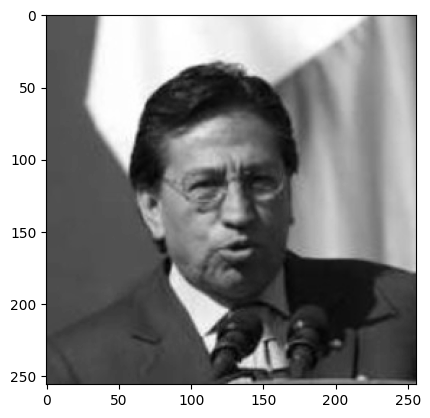

In [16]:
new = test_image
_ = plt.imshow(new, cmap="gray")

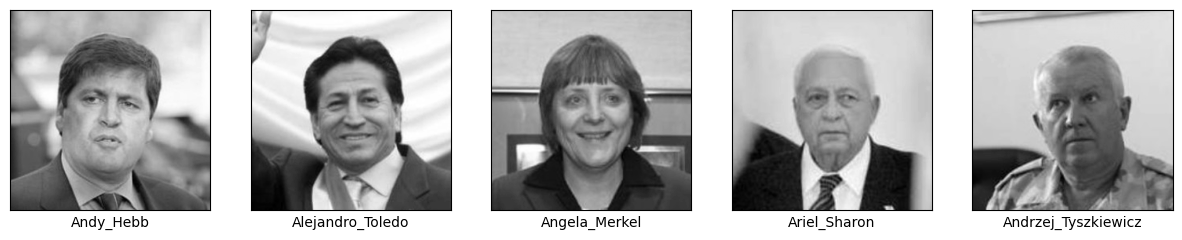

In [17]:
new_v = new.ravel(order="F")
names = sum(map(lambda item: [item[0]] * len(item[1]), images.items()), [])
show_images(M, get_closest_naive(M, new_v, 5), names)

Помимо того, что такой подход может оказаться неприемлемым с точки зрения производительности, он также не устойчив:  например, изменение освещения или фона может очень сильно изменить норму разности.

   2. **(20 баллов)** Применим подход, использующий SVD. Именно, спроецируем новое изображение на пространство, задаваемое ортонормированным базисом $U$, и будем сравнивать норму разности проекций. Причём для устойчивости к изменению освещения не будем учитывать первую компоненту в разложении по столбцам матрицы $U$. Напишите функцию `get_closest_proj`, которая возвращает индексы `count` изображений по описанному алгоритму.

In [18]:
def get_closest_proj(U, C, new_v, count):
    """
        Input
            U: orthonormal basis of columns of Mr
            C: coefficients in equality Mr = UC
            M: matrix of images
            new_v: new image as a vector of shape (size**2,)
            count: desired number of closest images

        Output
            indices: list (of len `count`) of indices of closest images
    """
    new_proj = U[:, 1:].T @ new_v # проекция нового изображения на пространство, задаваемое ортонормированным базисом U
    all_proj = U[:, 1:] @ C[1:, :]  # проекции всех ориг изображений
    proj = U[:, 1:] @ new_proj  # обратное преобразование проекции нового изображения через базис U (воссоздание изображения из проекции на базис) для единого формата с all_proj для сравнения
    matrix_proj = np.tile(proj, (all_proj.shape[1], 1)).T  # повторяем вектор proj all_proj.shape[1] раз чтобы потом заюзать для разницы
    difference = np.linalg.norm(all_proj - matrix_proj, axis=0)  # считаем норму разности
    indices = np.argsort(difference)[:count]  # сортируем и берем count первых

    return indices


Проверим подход с SVD  том же тестовом изображении. Правильно реализованный метод должен найти как минимум два изображения Алехандро.

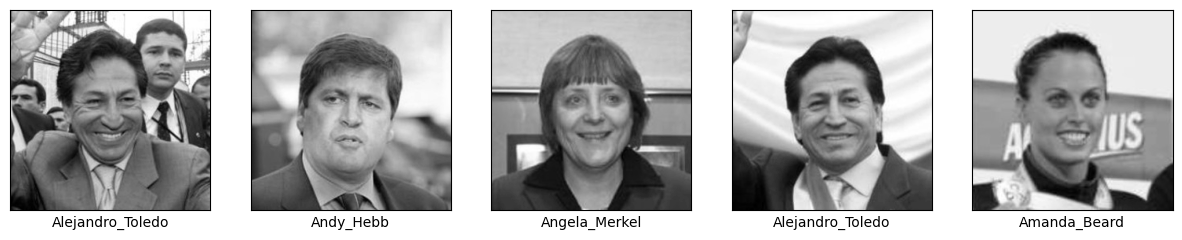

In [19]:
show_images(M, get_closest_proj(U, C, new_v, 5), names)

### c. Бонус

В бонусной части мы познакомимся с более продвинутыми рандомизированными алгоритмами поиска сингулярного разложения. Условие заданий базируется на статье 

Halko, Nathan, Per-Gunnar Martinsson, and Joel A. Tropp. "Finding structure with randomness: Probabilistic algorithms for constructing approximate matrix decompositions." SIAM review 53.2 (2011): 217-288.

**Ссылка на статью**: http://users.cms.caltech.edu/~jtropp/papers/HMT11-Finding-Structure-SIREV.pdf

1. **(50 б. баллов)** Докажите, что в точной арифметике результат, полученный при использовании Алгоритма 4.3 и 4.4 из статьи, указанной выше, совпадают. Все теоретические выкладки приведите в текущем файле с использованием Markdown или прикрепите качественное изображение рукописного текста.

2. **(50 б. баллов)** Реализуйте Алгоритм 4.4 и используйте его для построения приближенного сингулярного разложения матрицы A на матрице из этой ДЗ. Зафиксируйте ранги $r=5, 20, 50$. Для каждого из этих значений на одном рисунке постройте график зависимости нормы (на выбор) разности полученного приближения и оптимального приближения (в выбранной норме) того же ранга от числа q.

НОМЕР 2 тут полный бред вышел, но все же оставлю его тут

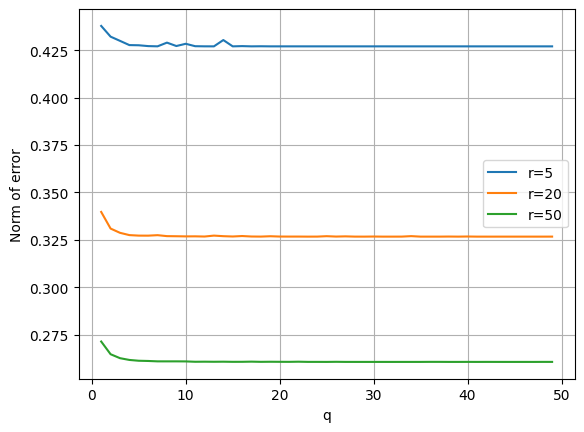

In [32]:
def randomized_subspace_iteration(A, l, q):
    # создаем случайную матрицу Omega
    Omega = np.random.normal(size=(A.shape[1], l))

    # считаем Y_0 и Q_0 через QR разложение
    Y_0 = A @ Omega
    Q_0, R_0 = np.linalg.qr(Y_0)

    # шаг 3
    Q_j = Q_0
    for j in range(q):
        Y_j = A.T @ Q_j
        Q_j, R_j = np.linalg.qr(Y_j)
        Y_j = A @ Q_j
        Q_j, R_j = np.linalg.qr(Y_j)

    # шаг 7
    Q = Q_j # возвращаем Q
    return Q

r_values = [5, 20, 50] # ранги
q_values = np.arange(1, 50) # q
errors = [] # список для хранения ошибок

for r in r_values:
    errors_r = []
    for q in q_values:
        Q = randomized_subspace_iteration(M, r, q) # получаем Q для r и q
        B = Q.T @ M # получаем B s.t. B = Q^T @ M
        U, S, Vt = np.linalg.svd(B, full_matrices=False) # сингулярное разложение B
        Mr = Q @ U[:, :r] @ np.diag(S[:r]) @ Vt[:r, :] # Mr = Q @ U_ @ S_ @ Vt_ (получаем Mr)
        error = np.linalg.norm(M - Mr, 'fro') / np.linalg.norm(M, 'fro') # считаем ошибку
        errors_r.append(error) # добавляем ошибку в список
    errors.append(errors_r)

for r, errors_r in zip(r_values, errors): # строим графики
    plt.plot(q_values, errors_r, label=f'r={r}') # строим график для каждого r
plt.xlabel('q')
plt.ylabel('Norm of error')
plt.legend()
plt.grid(True)
plt.show()

НОМЕР 1

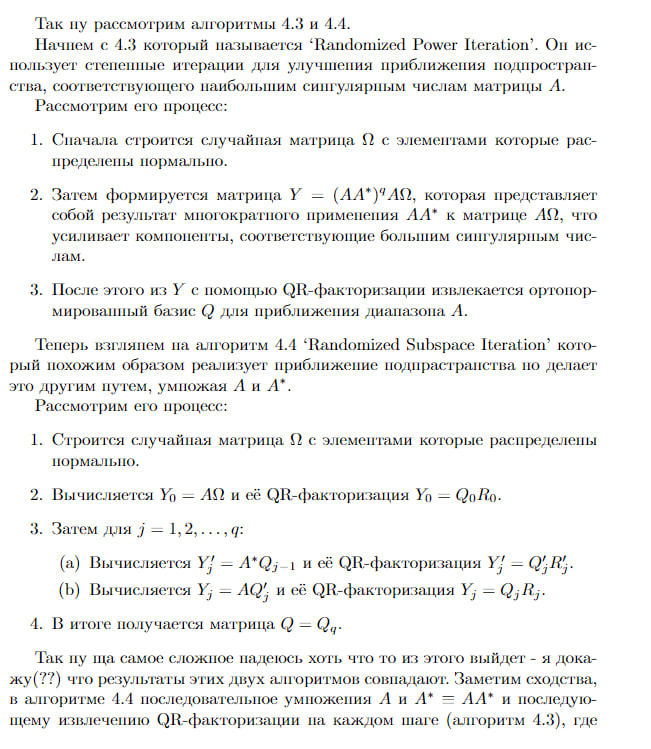

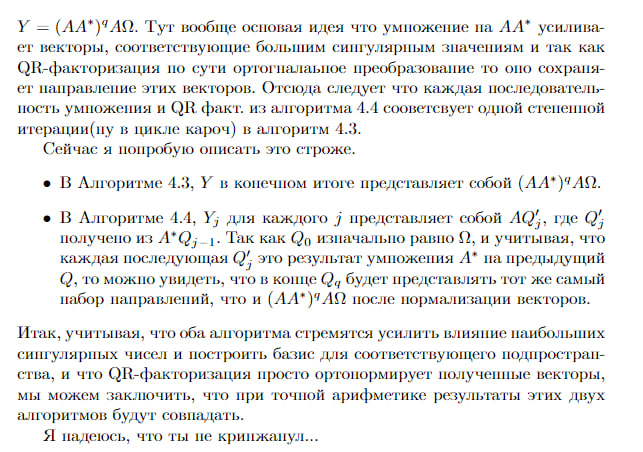

In [45]:
img1 = Image.open('data/photo_2024-02-24_19-07-08.jpg')
img2 = Image.open('data/2.jpg')
display(img1, img2)